## CHAT BOT using LangGraph

#### Imports 

In [34]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from typing import List, Annotated
from dotenv import load_dotenv
import operator
import os

load_dotenv()

True

#### LLM model initialization

In [35]:
model = ChatGoogleGenerativeAI(api_key=os.getenv("GOOGLE_API_KEY"), model="gemini-2.5-flash-lite", temperature=0)

#### Global State Defination 

In [36]:
class ChatBOTState(BaseModel):
    messages: Annotated[List[BaseMessage],add_messages]

#### Defining Functions of Each Agent 

In [37]:
def chat_bot(state: ChatBOTState) :
    
    response = model.invoke(state.messages)

    return {'messages':[response]}

#### Defining graph structures 

In [38]:
graph = StateGraph(ChatBOTState)

# add nodes

graph.add_node('chat_bot',chat_bot)

# add edges

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)


chat_bot_workflow = graph.compile() 

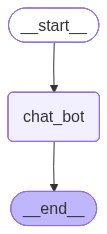

In [39]:
chat_bot_workflow

In [40]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india'),SystemMessage(content='You are a helpful assistant. only one sentence answer is required.')]
}

final_state = chat_bot_workflow.invoke(initial_state)

In [41]:
final_state

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='26d98338-2cda-4051-b994-0cf437d622bc'),
  SystemMessage(content='You are a helpful assistant. only one sentence answer is required.', additional_kwargs={}, response_metadata={}, id='b703b92d-8b38-403d-a63b-46ff1b5ee584'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019bbbc7-7a0c-7990-a3a4-6ac6b105c058-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 9, 'total_tokens': 16, 'input_token_details': {'cache_read': 0}})]}

In [44]:
final_state['messages'][-1].content

'The capital of India is **New Delhi**.'